# Outlier Detection from First Principles

**The problem.** You have training data for **30 classes** and you train a classifier on them.
At inference time, some inputs will belong to **classes that were never in the training set**.
The system must do two jobs at once:

1. **Classify** inputs from the 30 known classes as accurately as possible.
2. **Detect** inputs from unknown classes and reject them instead of forcing a wrong label.

You also have **60 labeled examples of outliers** collected so far. A large part of this notebook
is about what those 60 examples are — and are not — good for.

This task goes by several overlapping names: **out-of-distribution (OOD) detection**,
**open-set recognition**, **novelty detection**. We will build it from scratch:
every method is derived from a probabilistic argument and implemented in plain NumPy,
then evaluated the way you should evaluate it on your real data.

**Roadmap**

| § | Topic |
|---|-------|
| 1 | The open-set problem, stated precisely; why it is a density question |
| 2 | Why the classifier's own confidence fails (with a proof sketch and a picture) |
| 3 | Detection as density estimation: Mahalanobis, RMDS and kNN derived in 2-D |
| 4 | A realistic synthetic 30-class problem with near and far unknowns |
| 5 | The classifier and its feature space (post-hoc philosophy) |
| 6 | The score zoo: MSP, MaxLogit, Energy, Mahalanobis, Relative Mahalanobis, deep-kNN |
| 7 | Measuring detection quality: AUROC and FPR@95 implemented from scratch |
| 8 | Combining scores via conformal p-values |
| 9 | Choosing a threshold — and what the 60 outliers are actually for |
| 10 | The tempting mistake: training a supervised outlier classifier on 60 examples |
| 11 | The full open-set pipeline, end to end |
| 12 | Checklist for transferring this to your real problem |

Everything runs on NumPy / SciPy / scikit-learn / Matplotlib only.

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.stats import rankdata

# On Apple-Silicon Macs, the Accelerate BLAS that NumPy links against emits
# spurious "divide by zero / overflow encountered in matmul" RuntimeWarnings
# (a known false-positive bug in the backend, not a real numerical problem).
# Silence exactly those and nothing else.
warnings.filterwarnings("ignore", message=".*encountered in matmul")

rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def show_table(headers, rows, floatfmt="{:.3f}"):
    """Print a plain-text table (no pandas dependency)."""
    def fmt(v):
        if isinstance(v, float):
            return floatfmt.format(v)
        return str(v)
    str_rows = [[fmt(v) for v in row] for row in rows]
    widths = [max(len(h), *(len(r[i]) for r in str_rows)) for i, h in enumerate(headers)]
    line = "  ".join(h.ljust(w) for h, w in zip(headers, widths))
    print(line)
    print("-" * len(line))
    for r in str_rows:
        print("  ".join(v.ljust(w) for v, w in zip(r, widths)))

## 1. The open-set problem, stated precisely

**Closed-set classification** assumes a fixed label space. We observe training pairs
$(x_i, y_i)$ with $y_i \in \mathcal{Y} = \{1, \dots, 30\}$, drawn from a distribution
$p_{\text{in}}(x, y)$, and we learn $\hat p(y \mid x)$.

**Open-set classification** drops the assumption that test inputs come from $p_{\text{in}}$.
A test input is drawn from a mixture

$$
x \sim \pi \, p_{\text{in}}(x) + (1 - \pi)\, p_{\text{out}}(x),
$$

where $p_{\text{out}}$ is the distribution of the **unknown classes** — and, crucially,
$p_{\text{out}}$ is *not available at training time*. (Your 60 outliers are a tiny,
biased peek at it; more on that in §9.) The system must output

$$
F(x) \in \{1, \dots, 30\} \cup \{\texttt{reject}\}.
$$

The standard decomposition — which is also how every practical system is built — is a
**detector gate in front of a classifier**:

$$
F(x) = \begin{cases}
\arg\max_c \hat p(c \mid x) & \text{if } s(x) \ge \tau \\
\texttt{reject} & \text{if } s(x) < \tau,
\end{cases}
$$

where $s(x)$ is a scalar **knownness score** (high = looks like training data) and $\tau$
is a threshold. This notebook is about how to build $s$ and how to pick $\tau$.
(Rejecting *misclassified* known-class inputs is a related but distinct goal — Chow's classic
reject option; we come back to the distinction in §12.)

### 1.1 Why this is a density question — the Neyman–Pearson view

Deciding "is $x$ from the training distribution?" is a **hypothesis test**:

$$
H_0: x \sim p_{\text{in}} \qquad \text{vs.} \qquad H_1: x \sim p_{\text{out}}.
$$

The **Neyman–Pearson lemma** says the optimal test at any false-alarm level thresholds the
likelihood ratio $\Lambda(x) = p_{\text{out}}(x) / p_{\text{in}}(x)$: no other decision rule with
the same probability of rejecting genuine in-distribution points detects more outliers.

But we do not know $p_{\text{out}}$. If we assume outliers are **spread broadly** — roughly
uniform over the region where decisions happen — then $\Lambda(x) \propto 1 / p_{\text{in}}(x)$,
and the optimal rule reduces to

$$
\boxed{\text{reject } x \text{ when } p_{\text{in}}(x) \text{ is small.}}
$$

Three consequences that shape everything below:

1. **Every OOD detector is a density estimator in disguise.** The methods in §6 differ only
   in *which space* they estimate density in and *what shape* they assume for it.
2. **We never need calibrated densities** — only the *ordering* of points by $p_{\text{in}}$
   near the boundary of the data. Any monotone transform of $p_{\text{in}}$ is an equally good score.
   This is why crude, unnormalized surrogates work.
3. **The "broad $p_{\text{out}}$" assumption is exactly what fails for near-OOD** — unknown
   classes that live close to the known ones. When outliers concentrate near the data,
   *which* density model you use (and in which feature space) starts to matter a lot.
   That is why we will keep the 60 real outliers for validating the choice, rather than
   trusting theory alone.

### 1.2 What a discriminative classifier knows — and what it cannot know

A classifier trained with cross-entropy models $p(y \mid x, \, y \in \mathcal{Y})$ —
the class posterior *conditioned on the closed world*. By construction
$\sum_{c=1}^{30} \hat p(c \mid x) = 1$ **for every** $x$, including inputs from unknown classes.
The quantity we need, $p_{\text{in}}(x)$, is the *marginal* density of inputs — precisely the
factor a discriminative model discards. Bayes' rule makes the gap explicit:

$$
p(y \mid x) = \frac{p(x \mid y)\, p(y)}{p_{\text{in}}(x)}
\qquad\Longrightarrow\qquad
\text{posterior } \perp \text{ density: the } p_{\text{in}}(x) \text{ in the denominator cancels out.}
$$

So "the model is 99% confident" and "the model has seen anything like this" are logically
independent statements. §2 shows the failure concretely and §3 shows what to do instead.

## 2. Why the classifier's own confidence fails

Take the simplest probabilistic classifier: multinomial logistic (softmax) regression,

$$
\hat p(c \mid x) = \frac{e^{\ell_c(x)}}{\sum_{c'} e^{\ell_{c'}(x)}},
\qquad \ell_c(x) = w_c^\top x + b_c .
$$

**Claim: confidence $\to$ 1 along almost every ray to infinity.**
Walk away from the data along direction $u$, i.e. $x = t\,u$ with $t \to \infty$. Let
$c^\star = \arg\max_c w_c^\top u$ (unique for all $u$ outside a measure-zero set of ties). Then
for every other class $c$,

$$
\ell_{c^\star}(t u) - \ell_c(t u) = t\,(w_{c^\star} - w_c)^\top u + (b_{c^\star} - b_c) \to +\infty,
$$

so $\max_c \hat p(c \mid tu) \to 1$ **exponentially fast**. The classifier is *most* confident
where it has seen *no data at all*. Geometrically: linear logits carve **all of $\mathbb{R}^d$**
into 30 cones; every point, however remote, sits deep inside one of them, and softmax
confidence measures distance to the nearest *decision boundary* — not distance to the *data*.

This is not an artifact of linearity. ReLU networks are piecewise linear, and Hein et al.
(CVPR 2019) prove the same theorem for them: far enough along almost any ray, a ReLU
classifier is arbitrarily confident. Overconfidence far from data is a *structural* property
of discriminative models, not a training accident.

Let's see it. We train softmax regression on three well-separated 2-D clusters and plot,
over the whole plane: the maximum softmax probability (**MSP**), and — because §6 will
build scores directly from them — the **raw logits** themselves (their max, and their
logsumexp). The same theorem shows in two opposite ways: MSP *saturates* far from data,
while raw logit size *grows without bound* along every ray.

In [2]:
# --- A 2-D toy problem: 3 classes, 150 points each -------------------------
from sklearn.linear_model import LogisticRegression

toy_means = np.array([[-2.5, -1.5], [2.5, -1.5], [0.0, 2.8]])
toy_covs = np.array([
    [[0.55, 0.20], [0.20, 0.35]],
    [[0.45, -0.15], [-0.15, 0.55]],
    [[0.60, 0.00], [0.00, 0.30]],
])
n_per = 150
X_toy = np.vstack([rng.multivariate_normal(m, C, n_per) for m, C in zip(toy_means, toy_covs)])
y_toy = np.repeat(np.arange(3), n_per)

clf_toy = LogisticRegression(max_iter=1000).fit(X_toy, y_toy)
print(f"toy training accuracy: {clf_toy.score(X_toy, y_toy):.3f}")

# Two probe points: P1 is far from all data, P2 sits between clusters.
P1 = np.array([[8.0, 8.0]])
P2 = np.array([[0.0, -0.2]])
for name, P in [("P1 (far away)", P1), ("P2 (between clusters)", P2)]:
    conf = clf_toy.predict_proba(P).max()
    print(f"MSP at {name:22s}: {conf:.4f}")

toy training accuracy: 1.000
MSP at P1 (far away)         : 0.9999
MSP at P2 (between clusters) : 0.5164


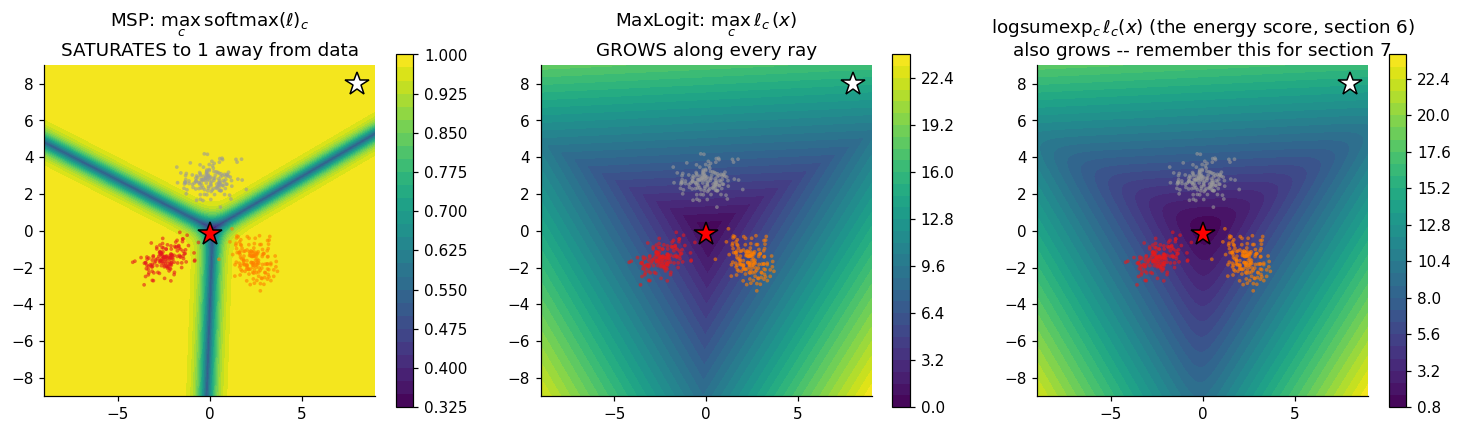

White star: far from all data.  Red star: between the clusters.


In [3]:
# --- Heatmap helper and the MSP picture -------------------------------------
GRID_LIM = (-9, 9)

def grid_eval(score_fn, lim=GRID_LIM, n=300):
    """Evaluate score_fn on an n x n grid; returns (xx, yy, values)."""
    xs = np.linspace(*lim, n)
    xx, yy = np.meshgrid(xs, xs)
    pts = np.column_stack([xx.ravel(), yy.ravel()])
    return xx, yy, score_fn(pts).reshape(xx.shape)

def plot_score_map(ax, score_fn, title, lim=GRID_LIM):
    xx, yy, zz = grid_eval(score_fn, lim)
    im = ax.contourf(xx, yy, zz, levels=30, cmap="viridis")
    ax.scatter(*X_toy.T, c=y_toy, cmap="Set1", s=6, alpha=0.6, edgecolors="none")
    ax.plot(*P1.T, marker="*", ms=16, c="white", mec="black", ls="none")
    ax.plot(*P2.T, marker="*", ms=16, c="red", mec="black", ls="none")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(False)
    return im

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9))
maps = [
    (lambda P: clf_toy.predict_proba(P).max(axis=1),
     "MSP: $\\max_c\\,\\mathrm{softmax}(\\ell)_c$\nSATURATES to 1 away from data"),
    (lambda P: clf_toy.decision_function(P).max(axis=1),
     "MaxLogit: $\\max_c\\,\\ell_c(x)$\nGROWS along every ray"),
    (lambda P: logsumexp(clf_toy.decision_function(P), axis=1),
     "logsumexp$_c\\,\\ell_c(x)$ (the energy score, section 6)\nalso grows -- remember this for section 7"),
]
for ax, (fn, title) in zip(axes, maps):
    im = plot_score_map(ax, fn, title)
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()
print("White star: far from all data.  Red star: between the clusters.")

The pictures confirm the theorem, twice:

- **Left (MSP):** confidence is low **only in thin slivers along the decision boundaries**
  and saturates to 1 everywhere else — including at the white star, which is nowhere near
  any training data. MSP is a fine detector of "am I near a decision boundary?" (which is
  why it is a decent *misclassification* detector), but it cannot tell "have I left the
  data." Note the red star between clusters gets a *lower* MSP than the absurd far point —
  exactly backwards for novelty detection.
- **Middle and right (the raw logits):** the opposite pathology. MaxLogit and
  logsumexp-of-logits *increase* radially outward forever — the farther you walk from the
  data, the "more confident" the raw logit landscape looks. File this picture away: §6
  builds the energy score from exactly this logsumexp, and §7 shows this radial growth
  ranking far outliers as *more* in-distribution than real data. The failure you will see
  there in a table, you have now seen here as geometry.

## 3. Detection as density estimation — derived in 2-D

§1 told us the right score is (any monotone transform of) $p_{\text{in}}(x)$. We now build the
two classic families of density surrogates, staying in 2-D where we can see everything.

### 3.1 Parametric route: Gaussians $\Rightarrow$ Mahalanobis distance

Model each known class as a Gaussian with a **shared covariance** (we justify sharing below):

$$
p(x \mid c) = \mathcal{N}(x;\, \mu_c, \Sigma), \qquad
p_{\text{in}}(x) = \sum_{c} \pi_c \, \mathcal{N}(x;\, \mu_c, \Sigma).
$$

Take logs of one component:

$$
\log \mathcal{N}(x; \mu_c, \Sigma)
= -\tfrac{1}{2} \underbrace{(x-\mu_c)^\top \Sigma^{-1} (x-\mu_c)}_{d_c^2(x),\ \text{squared Mahalanobis distance}}
\; -\; \tfrac{1}{2}\log\det(2\pi\Sigma).
$$

The second term is a constant, so **per class, log-density is a negative squared distance** —
but distance measured in the geometry of the data: writing $\Sigma = LL^\top$ (Cholesky),
$d_c(x) = \lVert L^{-1}(x - \mu_c) \rVert$. Mahalanobis distance is Euclidean distance
*after whitening*: directions in which the data naturally varies a lot count for less.

For the mixture, note that $\max_c$ bounds $\operatorname{logsumexp}_c$ within $\log C$
(for the 30-class problem, $\log 30 \approx 3.4$ nats), so with equal priors,

$$
\log p_{\text{in}}(x) \;\approx\; \text{const} - \tfrac{1}{2}\min_c d_c^2(x),
\qquad
\boxed{\, s_{\text{Maha}}(x) = -\min_c \, d_c^2(x) \,}
$$

— "how far is $x$ from the *nearest class center*, in whitened units."

**Why a shared $\Sigma$?** A full per-class covariance in $D$ dimensions has $D(D{+}1)/2$
parameters *per class*; with few samples per class the estimates are noisy and singular.
Pooling residuals across classes multiplies the effective sample size by 30. This is exactly
the LDA assumption — and it buys a beautiful consistency check: the class *posterior* of this
generative model is $\text{softmax}(w_c^\top x + b_c)$ with $w_c = \Sigma^{-1}\mu_c$ —
**the same functional form as logistic regression**. The generative and discriminative models
draw the same boundaries; the difference is that the generative one *retains* $p_{\text{in}}(x)$
while the discriminative one cancels it out (§1.2). Mahalanobis scoring simply refuses to
throw that factor away.

### 3.2 Non-parametric route: $k$-nearest-neighbor density

If we assume nothing about shape, the classic kNN density estimate comes from a counting
argument: in a ball of radius $r$ around $x$, the expected number of the $n$ training points
is $\approx n \, p(x) \, V_d \, r^d$ (with $V_d r^d$ the ball volume). Setting that count to $k$
and solving:

$$
\hat p(x) = \frac{k}{n \, V_d \, r_k(x)^d}
\qquad\Longrightarrow\qquad
\log \hat p(x) = \text{const} - d \log r_k(x),
$$

where $r_k(x)$ is the distance from $x$ to its $k$-th nearest training point. Log-density is
monotone in $-r_k$, so

$$
\boxed{\, s_{\text{kNN}}(x) = -\, r_k(x) \,}
$$

No Gaussian assumption, adapts to local scale and arbitrary cluster shapes; the price is
storing training points and paying a neighbor search at inference (cheap at your scale).

### 3.3 A better null hypothesis: relative (background-subtracted) distances

The Neyman–Pearson view (§1.1) said the ideal score is a likelihood *ratio* against the
outlier distribution, and "assume $p_{\text{out}}$ flat" reduced it to plain density. We can
do better with a **data-driven null**: fit one *background* Gaussian
$\mathcal{N}(\mu_0, \Sigma_0)$ to all training points with the labels thrown away, and score
each point by how much better its best *class* explains it than the background does:

$$
s_{\text{RMDS}}(x) = -\min_c \big[ d_c^2(x) - d_0^2(x) \big]
= 2 \max_c \log \frac{\mathcal{N}(x;\, \mu_c, \Sigma)}{\mathcal{N}(x;\, \mu_0, \Sigma_0)} + \text{const}.
$$

Unusualness that the background model *also* predicts — directions in which all the data
spreads — cancels out; what survives is **class-specific** unusualness. This is the
Relative Mahalanobis score (RMDS; Ren et al. 2021), one of the strongest near-OOD methods
in feature space (§6.2 puts it to work). Its 2-D signature, visible below: sharp structure
near the classes, but a *shallower* falloff far away — the background partially "explains
away" remote unusualness. That is why RMDS is a near-OOD specialist, and why we will keep
plain Mahalanobis and kNN alongside it rather than crowning any single score.

First let's *look at* the fitted models, then draw every score's map side by side.

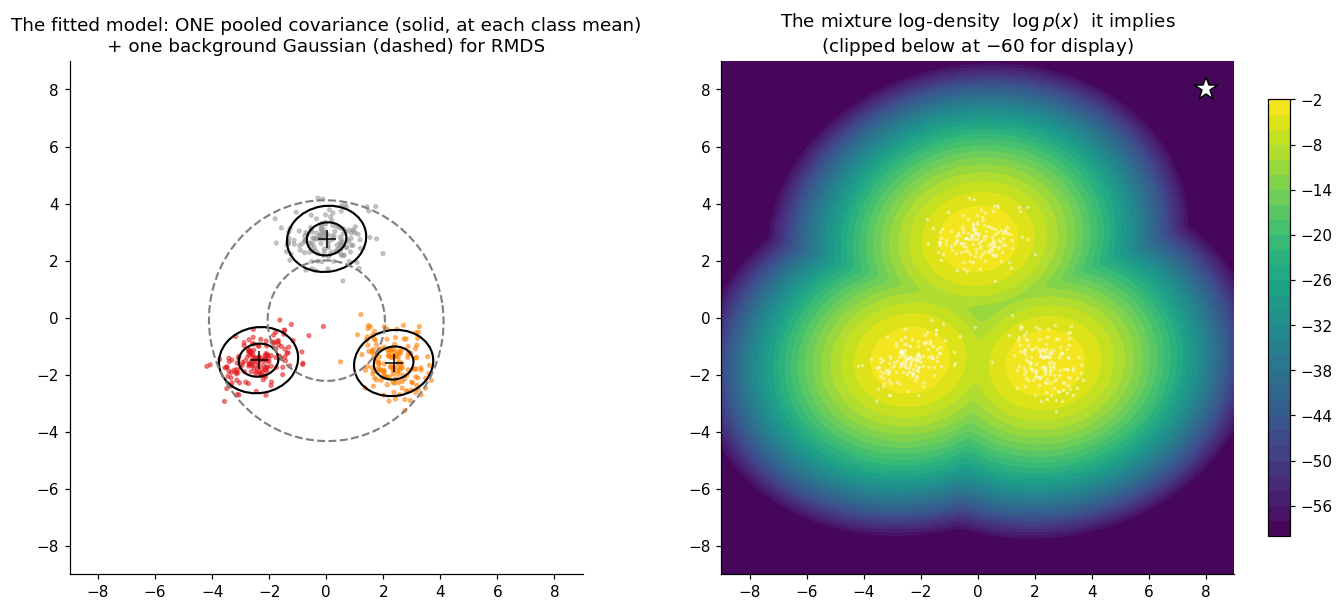

This is all the 'training' the detector needs: 3 means, 1 covariance, 1 background.


In [4]:
# --- Fit the 2-D generative models -- and draw what we fitted --------------------
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal

def fit_gaussians(X, y, n_classes):
    """Class means + pooled (shared) covariance from within-class residuals."""
    mus = np.stack([X[y == c].mean(axis=0) for c in range(n_classes)])
    resid = X - mus[y]                       # center every point by its class mean
    Sigma = resid.T @ resid / (len(X) - n_classes)
    return mus, Sigma

mus_toy, Sigma_toy = fit_gaussians(X_toy, y_toy, 3)
prec_toy = np.linalg.inv(Sigma_toy)
mu0_toy = X_toy.mean(axis=0)                 # background Gaussian: labels thrown away
Sigma0_toy = np.cov(X_toy.T)
prec0_toy = np.linalg.inv(Sigma0_toy)

def draw_ellipses(ax, mu, Sigma, sigmas, **kw):
    """Draw k-sigma iso-density ellipses of N(mu, Sigma)."""
    vals, vecs = np.linalg.eigh(Sigma)
    angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
    for k in sigmas:
        ax.add_patch(Ellipse(mu, 2 * k * np.sqrt(vals[-1]), 2 * k * np.sqrt(vals[0]),
                             angle=angle, fill=False, **kw))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

# left: the fitted machinery -- one covariance shape, three locations, one background
ax = axes[0]
ax.scatter(*X_toy.T, c=y_toy, cmap="Set1", s=6, alpha=0.5)
for m in mus_toy:
    draw_ellipses(ax, m, Sigma_toy, sigmas=(1, 2), color="black", lw=1.4)
    ax.plot(*m, marker="+", ms=12, c="black")
draw_ellipses(ax, mu0_toy, Sigma0_toy, sigmas=(1, 2), color="gray", lw=1.4, ls="--")
ax.set_title("The fitted model: ONE pooled covariance (solid, at each class mean)\n"
             "+ one background Gaussian (dashed) for RMDS")
ax.set_aspect("equal"); ax.grid(False)
ax.set_xlim(*GRID_LIM); ax.set_ylim(*GRID_LIM)

# right: the mixture density these Gaussians define
ax = axes[1]
logps = np.stack([multivariate_normal(m, Sigma_toy).logpdf
                  (np.column_stack([g.ravel() for g in np.meshgrid(
                      np.linspace(*GRID_LIM, 300), np.linspace(*GRID_LIM, 300))]))
                  for m in mus_toy])
mix_logp = logsumexp(logps, axis=0) - np.log(3)
xs = np.linspace(*GRID_LIM, 300)
xx, yy = np.meshgrid(xs, xs)
im = ax.contourf(xx, yy, np.clip(mix_logp, -60, None).reshape(xx.shape),
                 levels=30, cmap="viridis")
ax.scatter(*X_toy.T, c="white", s=2, alpha=0.35)
ax.plot(*P1.T, marker="*", ms=16, c="white", mec="black", ls="none")
ax.set_title("The mixture log-density  $\\log p(x)$  it implies\n(clipped below at $-60$ for display)")
ax.set_aspect("equal"); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout(); plt.show()
print("This is all the 'training' the detector needs: 3 means, 1 covariance, 1 background.")

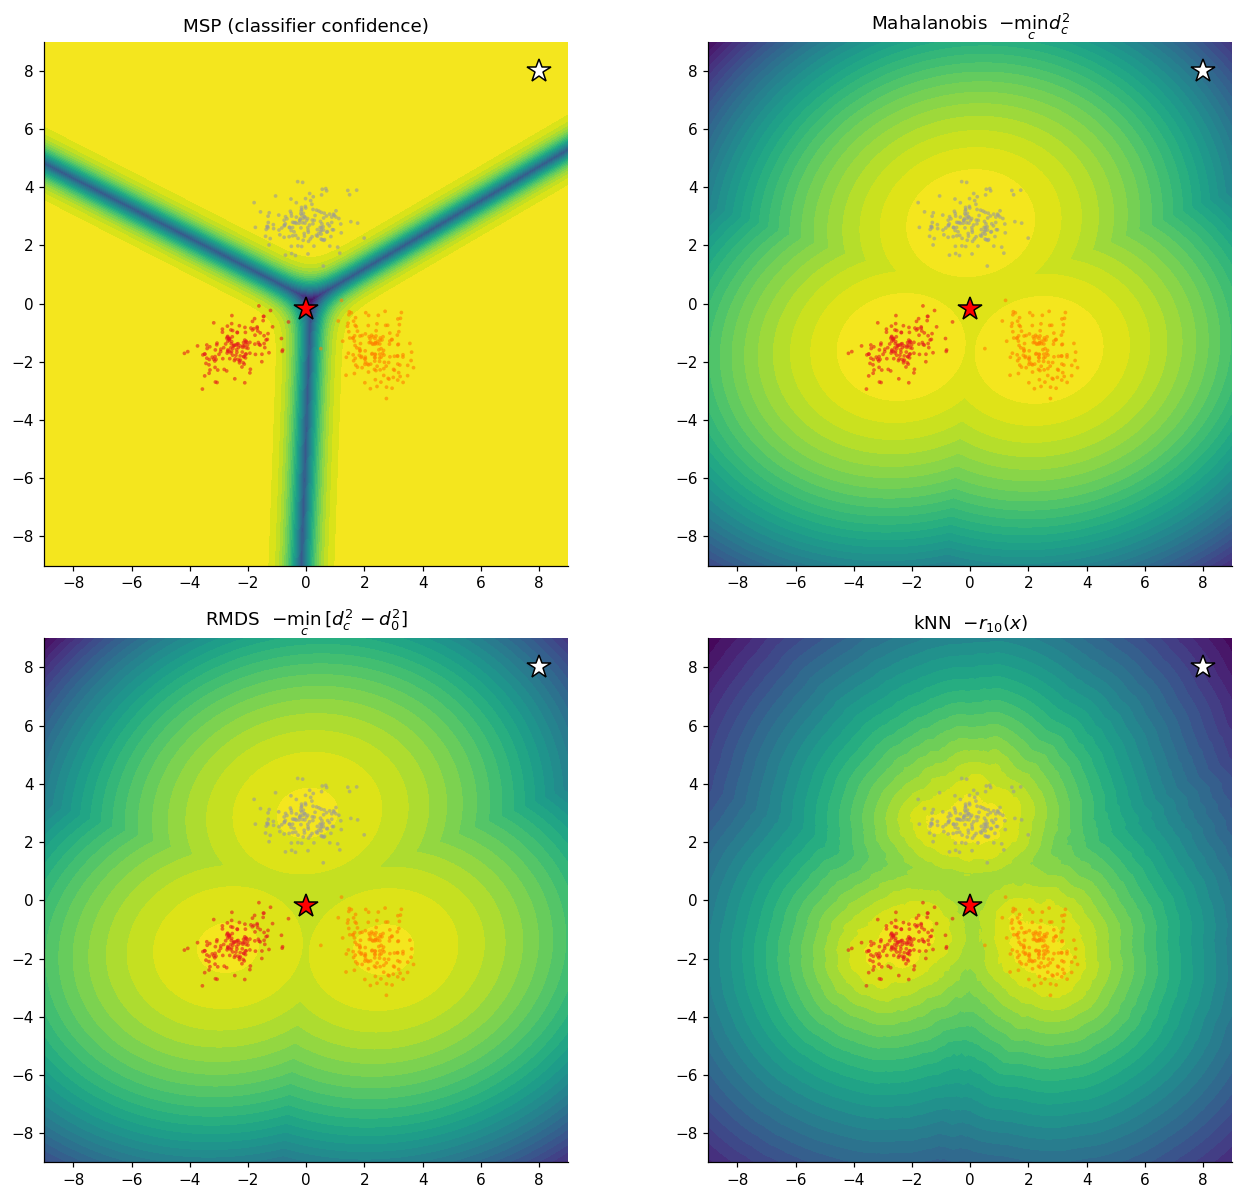

score                         far star P1  boundary star P2   (want: P1 << P2)
MSP                                 1.000             0.516
Mahalanobis                      -200.751           -15.670
RMDS                             -170.646           -15.668
kNN                                -8.489            -1.477


In [5]:
# --- Every score's map, side by side ------------------------------------------
from sklearn.neighbors import NearestNeighbors

def mahalanobis_score(P, mus, prec):
    """s(x) = -min_c (x-mu_c)^T prec (x-mu_c).  Vectorized over P and classes."""
    d2 = np.stack([np.einsum("nd,dk,nk->n", P - m, prec, P - m) for m in mus], axis=1)
    return -d2.min(axis=1)

def rmds_score_2d(P):
    """s(x) = -min_c [d_c^2(x) - d_0^2(x)]: class distance minus background distance."""
    d2c = np.stack([np.einsum("nd,dk,nk->n", P - m, prec_toy, P - m) for m in mus_toy], axis=1)
    d20 = np.einsum("nd,dk,nk->n", P - mu0_toy, prec0_toy, P - mu0_toy)
    return -(d2c - d20[:, None]).min(axis=1)

knn_toy = NearestNeighbors(n_neighbors=10).fit(X_toy)
def knn_score(P, nn):
    dists, _ = nn.kneighbors(P)
    return -dists[:, -1]                     # distance to k-th neighbor, negated

SCORES_2D = {
    "MSP (classifier confidence)": lambda P: clf_toy.predict_proba(P).max(axis=1),
    "Mahalanobis  $-\\min_c d_c^2$": lambda P: mahalanobis_score(P, mus_toy, prec_toy),
    "RMDS  $-\\min_c\\,[d_c^2 - d_0^2]$": rmds_score_2d,
    "kNN  $-r_{10}(x)$": lambda P: knn_score(P, knn_toy),
}
fig, axes = plt.subplots(2, 2, figsize=(12.5, 11))
for ax, (title, fn) in zip(axes.ravel(), SCORES_2D.items()):
    plot_score_map(ax, fn, title)
plt.tight_layout(); plt.show()

print(f"{'score':28s} {'far star P1':>12s} {'boundary star P2':>17s}   (want: P1 << P2)")
for name, fn in SCORES_2D.items():
    label = name.split("  ")[0].split(" (")[0]
    print(f"{label:28s} {fn(P1)[0]:12.3f} {fn(P2)[0]:17.3f}")

The density-based maps look completely different from MSP: score falls off **in every
direction away from the data**, and the far star is now (correctly) the most anomalous
point in the frame. The red star between clusters — a plausible place for real inputs to
land — scores *higher* than the remote one, the ordering MSP got backwards. Compare the
Mahalanobis and RMDS panels closely: near the classes they agree, but far out the RMDS map
decays visibly more gently — the background subtraction at work, exactly as §3.3 predicted.

One last picture compresses the entire section into a single line each: walk along the ray
from a class center out through the far star, and watch every score react.

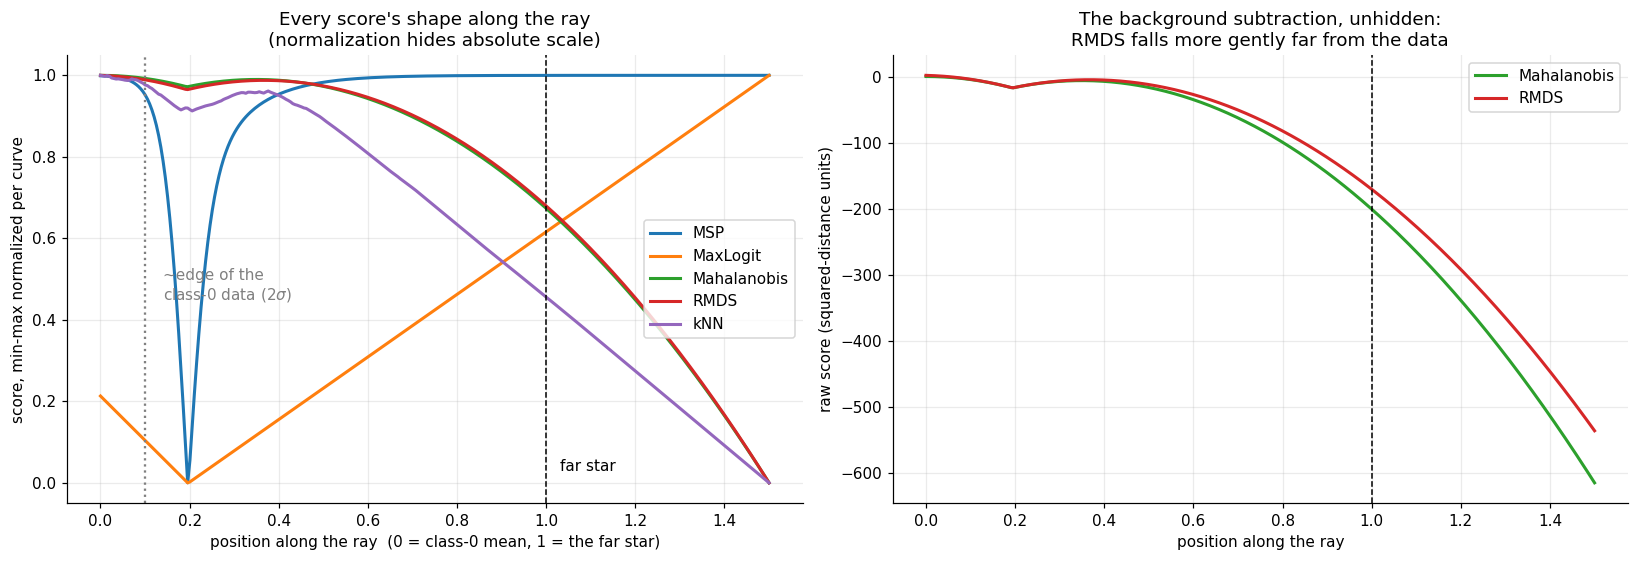

At the far star: Mahalanobis -201, RMDS -171 -- the background Gaussian 'explains away' part of the remoteness.


In [6]:
# --- Walking away from the data: every score along one ray ----------------------
t = np.linspace(0, 1.5, 300)
ray = mus_toy[0] + t[:, None] * (P1[0] - mus_toy[0])   # t=0: class-0 mean, t=1: far star

RAY_SCORES = {
    "MSP": lambda P: clf_toy.predict_proba(P).max(axis=1),
    "MaxLogit": lambda P: clf_toy.decision_function(P).max(axis=1),
    "Mahalanobis": lambda P: mahalanobis_score(P, mus_toy, prec_toy),
    "RMDS": rmds_score_2d,
    "kNN": lambda P: knn_score(P, knn_toy),
}
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# left: every score's SHAPE along the ray (min-max normalized per curve)
ax = axes[0]
for name, fn in RAY_SCORES.items():
    s = fn(ray)
    s = (s - s.min()) / (s.max() - s.min())
    ax.plot(t, s, lw=2, label=name)
edge = 2 * np.sqrt(np.linalg.eigvalsh(Sigma_toy)[-1]) / np.linalg.norm(P1[0] - mus_toy[0])
ax.axvline(edge, color="gray", ls=":", lw=1.5)
ax.annotate("~edge of the\nclass-0 data (2$\\sigma$)", xy=(edge, 0.5),
            xytext=(edge + 0.04, 0.45), color="gray")
ax.axvline(1.0, color="black", ls="--", lw=1)
ax.annotate("far star", xy=(1.0, 0.03), xytext=(1.03, 0.03))
ax.set_xlabel("position along the ray  (0 = class-0 mean, 1 = the far star)")
ax.set_ylabel("score, min-max normalized per curve")
ax.set_title("Every score's shape along the ray\n(normalization hides absolute scale)")
ax.legend(loc="center right")

# right: Mahalanobis vs RMDS on their RAW, comparable scale (-squared distances) --
# normalization above makes their shapes coincide; the real difference is decay RATE.
ax = axes[1]
ax.plot(t, mahalanobis_score(ray, mus_toy, prec_toy), lw=2, c="tab:green", label="Mahalanobis")
ax.plot(t, rmds_score_2d(ray), lw=2, c="tab:red", label="RMDS")
ax.axvline(1.0, color="black", ls="--", lw=1)
ax.set_xlabel("position along the ray")
ax.set_ylabel("raw score (squared-distance units)")
ax.set_title("The background subtraction, unhidden:\nRMDS falls more gently far from the data")
ax.legend()
plt.tight_layout(); plt.show()
print("At the far star: Mahalanobis", f"{mahalanobis_score(P1, mus_toy, prec_toy)[0]:.0f},",
      "RMDS", f"{rmds_score_2d(P1)[0]:.0f}",
      "-- the background Gaussian 'explains away' part of the remoteness.")

Read the curves left to right:

- **MSP** drops briefly where the ray crosses near a decision boundary, then snaps back to
  its ceiling and stays there — by the far star it is maximally "confident" again.
- **MaxLogit** *rises* monotonically once outside the data — the §2 growth pathology as a
  single curve. (Energy, its smooth sibling, tracks it.)
- **Mahalanobis, RMDS and kNN** fall the moment the ray leaves the cluster and, past
  $t \approx 0.4$, never look back — apart from one small, *correct* flicker around
  $t \approx 0.2$–$0.35$, where the ray skims class 2's cluster and the density scores
  briefly perk up. That bump is a feature, not a bug: the mixture density genuinely rises
  there, and a faithful density surrogate should say so. After per-curve normalization,
  Mahalanobis and RMDS coincide almost exactly, while kNN — a *distance*, not a *squared*
  distance — bends differently and sits visibly below them mid-ray. Yet all three decay in
  the same direction and induce the same ordering along the ray, which is the §7 lesson in
  miniature: *ordering is all a score is*.
- The **right panel** removes the normalization and compares Mahalanobis and RMDS on their
  raw, common scale (RMDS is a *difference* of squared distances, so unlike Mahalanobis it
  can be positive — visible at $t = 0$): RMDS sits above and falls more gently as distance
  grows — the background subtraction "explaining away" part of the remoteness. That is the
  trade RMDS makes: some far-OOD sharpness exchanged for near-OOD precision.

That is the whole conceptual content of OOD detection, in one figure. Everything from here
on is engineering the same ideas to work in **high dimensions, on learned features, with
honest evaluation**.

## 4. A realistic 30-class problem

We now build a synthetic dataset shaped like your real one. Design choices, and why:

- **Latent structure + nonlinear observation.** Each class lives in an 8-D latent space and is
  pushed through a fixed random nonlinear map into $D = 64$ observed dimensions. Raw inputs are
  therefore *not* Gaussian-per-class — like real data — which is exactly why we will score in a
  *learned feature space* rather than input space (§5).
- **30 known classes** with training / validation / test splits.
- **8 unknown classes** the classifier never sees, of two kinds:
  **near-OOD** (5 classes drawn from the *same* latent prior as the knowns — new-but-similar
  categories, the hard case) and **far-OOD** (3 classes with latent means pushed far out —
  the easy case). Reporting these separately matters: near and far difficulty differ by a lot,
  and a method ranking can even flip between them.
- **60 calibration outliers, from only 3 of the 8 unknown classes** (20 each). This mirrors
  reality: the outliers you happened to collect are *not* a fair sample of all future novelty.
  The remaining 5 unknown classes are **unseen-class outliers** — they exist only in the test
  set, and they are how we will detect over-fitting to the 60 (§10).

Split discipline (leakage kills OOD evaluations silently — worth being pedantic):

| split | size | role |
|---|---|---|
| `train` | 30×200 | fit classifier + all density models |
| `val_A` | 30×60 | calibrate per-score ECDFs (p-values, §8) |
| `val_B` | 30×40 | conformal threshold for the *combined* score (§9) |
| `test_id` | 30×80 | measure false-reject rate + closed-set accuracy; ID side of the §9.1 selection AUROCs |
| `out_cal` | 60 | the 60 collected outliers: model *selection* + threshold sanity check |
| `out_test_seen` | 3×150 | fresh samples from the 3 outlier classes we have seen |
| `out_test_unseen` | 5×150 | samples from the 5 outlier classes we have never seen |

In [7]:
# --- Synthetic data generator ------------------------------------------------
LATENT_D, OBS_D = 8, 64
N_KNOWN, N_NEAR, N_FAR = 30, 5, 3
MEAN_SCALE = 1.9           # controls class overlap => closed-set difficulty

# Latent class means: knowns and near-OOD from the same prior; far-OOD pushed out.
means_known = rng.normal(size=(N_KNOWN, LATENT_D)) * MEAN_SCALE
means_near  = rng.normal(size=(N_NEAR, LATENT_D)) * MEAN_SCALE
means_far   = rng.normal(size=(N_FAR, LATENT_D)) * MEAN_SCALE * 2.6
class_scales = rng.uniform(0.6, 0.95, size=N_KNOWN + N_NEAR + N_FAR)  # per-class spread

# Fixed random nonlinear decoder: x = zA + 0.7*tanh(zW1)W2 + noise
A_dec  = rng.normal(size=(LATENT_D, OBS_D)) / np.sqrt(LATENT_D)
W1_dec = rng.normal(size=(LATENT_D, 32)) * (1.5 / np.sqrt(LATENT_D))
W2_dec = rng.normal(size=(32, OBS_D)) / np.sqrt(32)

def sample_class(mean, scale, n):
    z = mean + rng.normal(size=(n, LATENT_D)) * scale
    x = z @ A_dec + 0.7 * np.tanh(z @ W1_dec) @ W2_dec
    return x + 0.05 * rng.normal(size=(n, OBS_D))

def sample_split(means, scales, n_per):
    X = np.vstack([sample_class(m, s, n_per) for m, s in zip(means, scales)])
    y = np.repeat(np.arange(len(means)), n_per)
    return X, y

sc_known = class_scales[:N_KNOWN]
sc_near  = class_scales[N_KNOWN:N_KNOWN + N_NEAR]
sc_far   = class_scales[N_KNOWN + N_NEAR:]

X_train, y_train = sample_split(means_known, sc_known, 200)
X_valA,  y_valA  = sample_split(means_known, sc_known, 60)
X_valB,  y_valB  = sample_split(means_known, sc_known, 40)
X_test,  y_test  = sample_split(means_known, sc_known, 80)

# Unknown classes. "Seen" outlier classes (source of the 60): near #0, near #1, far #0.
SEEN_NEAR, SEEN_FAR = [0, 1], [0]
UNSEEN_NEAR, UNSEEN_FAR = [2, 3, 4], [1, 2]

X_out_cal = np.vstack(
    [sample_class(means_near[i], sc_near[i], 20) for i in SEEN_NEAR]
    + [sample_class(means_far[i], sc_far[i], 20) for i in SEEN_FAR])

def outlier_test(near_ids, far_ids, n_per=150):
    X = np.vstack([sample_class(means_near[i], sc_near[i], n_per) for i in near_ids]
                  + [sample_class(means_far[i], sc_far[i], n_per) for i in far_ids])
    is_near = np.repeat([True] * len(near_ids) + [False] * len(far_ids), n_per)
    return X, is_near

X_out_seen,   near_seen   = outlier_test(SEEN_NEAR, SEEN_FAR)
X_out_unseen, near_unseen = outlier_test(UNSEEN_NEAR, UNSEEN_FAR)

# Near/far regrouping across all test outliers (for the main comparison table).
X_out_all  = np.vstack([X_out_seen, X_out_unseen])
near_all   = np.concatenate([near_seen, near_unseen])
X_out_near, X_out_far = X_out_all[near_all], X_out_all[~near_all]

print(f"train {X_train.shape}, val_A {X_valA.shape}, val_B {X_valB.shape}, test_id {X_test.shape}")
print(f"out_cal {X_out_cal.shape}, out_test_seen {X_out_seen.shape}, out_test_unseen {X_out_unseen.shape}")
print(f"near-OOD test total {X_out_near.shape[0]}, far-OOD test total {X_out_far.shape[0]}")

train (6000, 64), val_A (1800, 64), val_B (1200, 64), test_id (2400, 64)
out_cal (60, 64), out_test_seen (450, 64), out_test_unseen (750, 64)
near-OOD test total 750, far-OOD test total 450


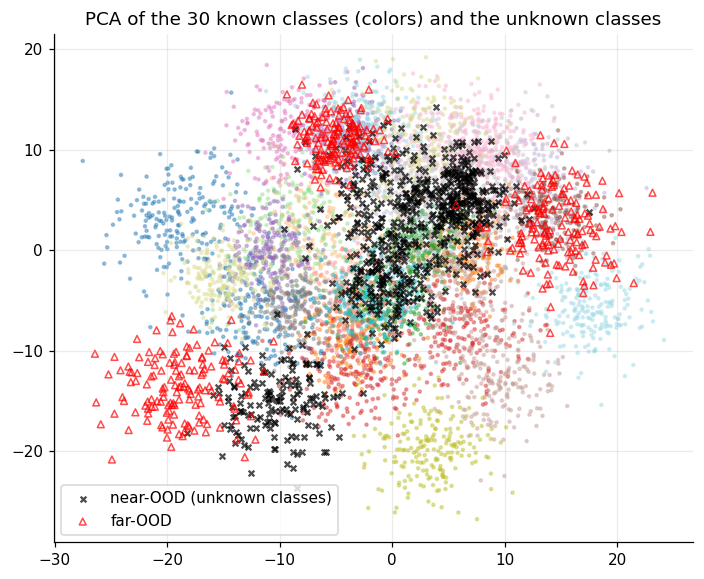

Near-OOD overlaps the known classes in this projection - that is what makes it hard.


In [8]:
# --- Look at it: PCA to 2-D --------------------------------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit(X_train)
Zt = pca.transform(X_train)
Zn = pca.transform(X_out_near)
Zf = pca.transform(X_out_far)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(*Zt.T, c=y_train, cmap="tab20", s=4, alpha=0.4, label=None)
ax.scatter(*Zn.T, marker="x", c="black", s=14, alpha=0.7, label="near-OOD (unknown classes)")
ax.scatter(*Zf.T, marker="^", facecolors="none", edgecolors="red", s=20, alpha=0.7, label="far-OOD")
ax.set_title("PCA of the 30 known classes (colors) and the unknown classes")
ax.legend()
plt.show()
print("Near-OOD overlaps the known classes in this projection - that is what makes it hard.")

## 5. The classifier and its feature space

We train an ordinary MLP classifier on the 30 known classes — standing in for whatever
classifier you already have. The detection philosophy throughout is **post-hoc**: we do not
change the classifier or its training in any way; we only *read things out of it*:

- the **logits** $\ell(x) \in \mathbb{R}^{30}$ (pre-softmax outputs), and
- the **penultimate-layer features** $z(x) \in \mathbb{R}^{64}$ (activations feeding the
  final linear layer).

Why the penultimate space? Cross-entropy training explicitly shapes it so that classes form
compact, linearly separable clusters — it is the space in which the network *itself* is doing
nearest-prototype classification via its final linear layer ($\ell_c = w_c^\top z + b_c$).
Class-conditional Gaussians and kNN, which were dubious in raw input space (our inputs are
deliberately non-Gaussian), become reasonable again in $z$-space. Lee et al. (NeurIPS 2018)
built the original Mahalanobis detector on exactly this observation.

If your real classifier is not a neural network (say gradient boosting), the same recipe
applies with two substitutions: use the model's margin/logit outputs for the logit-based
scores, and any good vector representation of your inputs for the distance-based scores.

`MLPClassifier` does not expose intermediate activations, so we re-implement its forward pass
from the learned weights — and *verify* it reproduces `predict_proba` exactly, so we know the
features are the real ones.

In [9]:
# --- Train the classifier and extract logits + penultimate features ----------
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(128, 64), alpha=1e-4, max_iter=1000,
                    random_state=0).fit(X_train, y_train)

def forward(X):
    """Manual forward pass: returns (penultimate features, logits)."""
    h = X
    for W, b in zip(mlp.coefs_[:-1], mlp.intercepts_[:-1]):
        h = np.maximum(h @ W + b, 0.0)               # ReLU hidden layers
    logits = h @ mlp.coefs_[-1] + mlp.intercepts_[-1]
    return h, logits

def softmax(logits):
    return np.exp(logits - logsumexp(logits, axis=1, keepdims=True))

# Verify our forward pass IS the model's.
_, logits_check = forward(X_test)
assert np.allclose(softmax(logits_check), mlp.predict_proba(X_test), atol=1e-8)
print("forward-pass check: softmax(logits) == mlp.predict_proba  [OK]")

acc = (logits_check.argmax(axis=1) == y_test).mean()
print(f"closed-set test accuracy on the 30 known classes: {acc:.3f}")

# Features and logits for every split we will need.
SPLITS = {
    "train": X_train, "val_A": X_valA, "val_B": X_valB, "test_id": X_test,
    "out_cal": X_out_cal, "out_seen": X_out_seen, "out_unseen": X_out_unseen,
    "out_near": X_out_near, "out_far": X_out_far, "out_all": X_out_all,
}
FEAT, LOGIT = {}, {}
for k, X in SPLITS.items():
    FEAT[k], LOGIT[k] = forward(X)
print(f"penultimate feature dim: {FEAT['train'].shape[1]}")

forward-pass check: softmax(logits) == mlp.predict_proba  [OK]
closed-set test accuracy on the 30 known classes: 0.965
penultimate feature dim: 64


## 6. The score zoo

Every score below is a monotone surrogate for "$p_{\text{in}}(x)$ in some space," per §1.
Convention: **higher score = more in-distribution**, always.

### 6.1 Reading density out of the logits: MSP, MaxLogit, Energy

**MSP** $\; s(x) = \max_c \operatorname{softmax}(\ell(x))_c$ — the §2 baseline. Weak for
novelty, but it is the standard baseline and occasionally surprisingly hard to beat, so it
stays in the table.

**Energy score.** Here is the first-principles derivation. *Pretend* the logits define an
unnormalized joint model over (input, class):

$$
\tilde p(x, c) \propto e^{\ell_c(x)} \quad\Longrightarrow\quad
\tilde p(x) \propto \sum_{c=1}^{30} e^{\ell_c(x)} = \exp\Big(\operatorname{logsumexp}_c \ell_c(x)\Big).
$$

So under this reading, $\operatorname{logsumexp}$ of the logits **is** an unnormalized
log-density of $x$ — exactly the quantity §1 asked for. With a temperature:

$$
s_{\text{energy}}(x) = T \cdot \operatorname{logsumexp}_c\big(\ell_c(x) / T\big),
$$

(Liu et al., NeurIPS 2020; this is $-E(x)$ in their notation). Honesty requires one caveat:
cross-entropy training only constrains logit *differences* — adding any function $g(x)$ to all
logits leaves the softmax unchanged — so nothing *forces* the absolute logit scale to track
density. Empirically it often does anyway: feature norms (and hence logit magnitudes) tend to grow in
regions the network saw densely during training. Energy is free and frequently strong — but
this caveat is not academic: §2's right-hand panel already showed the logsumexp landscape
*growing* along every ray, and §7 will show that geometry biting hard on our data. Treat
energy as a *candidate* to be validated, never as a score to be trusted on faith.

**MaxLogit** $\; s(x) = \max_c \ell_c(x)$ is the $T \to 0$ limit of the energy score
(logsumexp $\to$ max), trading a little smoothness for simplicity.

### 6.2 Explicit density in feature space: Mahalanobis and Relative Mahalanobis

Exactly §3.1, but on penultimate features $z(x)$: fit per-class means $\mu_c$ and a pooled
covariance $\Sigma$ on **training features**, score
$s_{\text{Maha}}(x) = -\min_c (z - \mu_c)^\top \Sigma^{-1} (z - \mu_c)$.

One practical amendment: in $D = 64$ dimensions, $\Sigma$ has 2,080 free parameters, and the
ReLU features are non-negative with many near-zero coordinates, so the raw pooled estimate can
be ill-conditioned. We use the **Ledoit–Wolf shrinkage** estimator
$\hat\Sigma_{\text{LW}} = (1-\lambda)\hat\Sigma + \lambda\,\bar\sigma^2 I$, which picks the
shrinkage weight $\lambda$ analytically to minimize expected squared error. In your real
problem (fewer samples per class), shrinkage is not optional — an unshrunk covariance is the
single most common way a Mahalanobis detector silently breaks.

**Relative Mahalanobis (RMDS)** (Ren et al., 2021) — §3.3's background-subtracted score,
now in feature space. The plain Mahalanobis score confounds two things: "far from class
$c$" and "in a low-density direction of the data *overall*." Fit a second, **background**
Gaussian $\mathcal{N}(\mu_0, \Sigma_0)$ to *all* training features pooled (no class
labels), and score with the **log-likelihood ratio** between the two models:

$$
s_{\text{RMDS}}(x) = -\min_c \Big[ d_c^2(x) - d_0^2(x) \Big]
\;=\; 2\,\max_c \log \frac{\mathcal{N}(z; \mu_c, \Sigma)}{\mathcal{N}(z; \mu_0, \Sigma_0)} + \text{const}.
$$

Intuition: $d_0^2$ measures "unusualness that is shared by all classes" — nuisance directions,
global scale — and subtracting it isolates *class-specific* unusualness. This is a
Neyman–Pearson test again, now with a data-driven null. RMDS is one of the most reliable
near-OOD scores on standard benchmarks, which is why it was the anchor recommendation for
your problem.

### 6.3 Non-parametric in feature space: deep-kNN

Exactly §3.2 on features — with one important twist from Sun et al. (ICML 2022):
**L2-normalize the features first**, $\hat z = z / \lVert z \rVert$, then use the distance to
the $k$-th nearest *training* feature:

$$
s_{\text{kNN}}(x) = -\big\lVert \hat z(x) - \hat z_{(k)} \big\rVert.
$$

Why normalize? Feature *norm* in a ReLU net correlates strongly with classifier confidence
(it is essentially the logit scale — the same signal energy already captures). Normalization
removes that confound so kNN measures *directional* novelty, complementary to energy rather
than redundant with it. As a bonus, distances on the unit sphere are better behaved in high
dimensions than raw Euclidean ones.

Choice of $k$: results are famously flat in $k$ over a wide range (10–100 at this data size);
we use $k = 25$ and note that if your results *do* depend sharply on $k$, that itself is a
warning sign worth investigating.

In [10]:
# --- Implement the zoo --------------------------------------------------------
from sklearn.covariance import LedoitWolf

# ---- logit-based scores ----
def score_msp(split):
    return softmax(LOGIT[split]).max(axis=1)

def score_maxlogit(split):
    return LOGIT[split].max(axis=1)

def score_energy(split, T=1.0):
    return T * logsumexp(LOGIT[split] / T, axis=1)

# ---- Mahalanobis family (fit on TRAIN features only) ----
n_classes = 30
mu_c = np.stack([FEAT["train"][y_train == c].mean(axis=0) for c in range(n_classes)])
resid = FEAT["train"] - mu_c[y_train]
lw_class = LedoitWolf().fit(resid)              # pooled within-class covariance, shrunk
prec_class = lw_class.precision_
print(f"Ledoit-Wolf shrinkage (class covariance): {lw_class.shrinkage_:.3f}")

lw_bg = LedoitWolf().fit(FEAT["train"])         # background Gaussian on all features
mu_0, prec_bg = FEAT["train"].mean(axis=0), lw_bg.precision_

def _sq_maha(Z, mus, prec):
    return np.stack([np.einsum("nd,dk,nk->n", Z - m, prec, Z - m) for m in mus], axis=1)

def score_maha(split):
    return -_sq_maha(FEAT[split], mu_c, prec_class).min(axis=1)

def score_rmds(split):
    d2_c = _sq_maha(FEAT[split], mu_c, prec_class)
    d2_0 = np.einsum("nd,dk,nk->n", FEAT[split] - mu_0, prec_bg, FEAT[split] - mu_0)
    return -(d2_c - d2_0[:, None]).min(axis=1)

# ---- deep-kNN on L2-normalized features ----
def l2norm(Z):
    return Z / np.clip(np.linalg.norm(Z, axis=1, keepdims=True), 1e-12, None)

K_NN = 25
nn_feat = NearestNeighbors(n_neighbors=K_NN).fit(l2norm(FEAT["train"]))

def score_knn(split):
    d, _ = nn_feat.kneighbors(l2norm(FEAT[split]))
    return -d[:, -1]

SCORES = {
    "MSP": score_msp, "MaxLogit": score_maxlogit, "Energy": score_energy,
    "Mahalanobis": score_maha, "RMDS": score_rmds, "kNN": score_knn,
}
# Sanity print: mean score on ID test vs far-OOD should already separate.
for name, fn in SCORES.items():
    print(f"{name:12s} mean score  ID test {fn('test_id').mean():9.3f}   far-OOD {fn('out_far').mean():9.3f}")

Ledoit-Wolf shrinkage (class covariance): 0.004
MSP          mean score  ID test     0.989   far-OOD     0.950
MaxLogit     mean score  ID test    29.150   far-OOD    37.010
Energy       mean score  ID test    29.163   far-OOD    37.071


Mahalanobis  mean score  ID test   -60.602   far-OOD -1004.258


RMDS         mean score  ID test    -2.017   far-OOD  -295.633
kNN          mean score  ID test    -0.269   far-OOD    -0.510


## 7. Measuring detection quality — from scratch

Detection quality must be measured **threshold-free** first (compare scores), and only then
at an operating point (§9). The two standard numbers:

**AUROC.** For score $s$, in-distribution samples $S_{\text{in}}$ and outliers $S_{\text{out}}$,

$$
\mathrm{AUROC} = \Pr\big(s(X_{\text{in}}) > s(X_{\text{out}})\big) + \tfrac{1}{2}\Pr\big(s(X_{\text{in}}) = s(X_{\text{out}})\big),
$$

i.e. the probability that a random ID point outranks a random outlier. It equals the area
under the ROC curve, and it is the **Mann–Whitney U statistic** rescaled — which gives the
efficient implementation: rank all scores jointly, sum the ID ranks. 0.5 = coin flip,
1.0 = perfect separation, and it is invariant to any monotone transform of the score
(consistent with §1: only the ordering matters).

**FPR@95TPR.** AUROC averages over all thresholds, including useless ones. Operationally you
care about one regime: *when the threshold is set to keep 95% of good inputs, what fraction of
outliers still gets through?* Lower is better. Two detectors with equal AUROC can differ a lot
here — always report both.

We implement both in a few lines and verify AUROC against scikit-learn.

In [11]:
# --- Metrics -------------------------------------------------------------------
from sklearn.metrics import roc_auc_score

def auroc(s_in, s_out):
    """P(s_in > s_out) + 0.5 P(=) via joint ranking (Mann-Whitney)."""
    s = np.concatenate([s_in, s_out])
    r = rankdata(s)                                   # average ranks handle ties
    n_in, n_out = len(s_in), len(s_out)
    u = r[:n_in].sum() - n_in * (n_in + 1) / 2
    return u / (n_in * n_out)

def fpr_at_tpr(s_in, s_out, tpr=0.95):
    """Fraction of outliers accepted when the threshold keeps `tpr` of ID."""
    tau = np.quantile(s_in, 1 - tpr)
    return (s_out >= tau).mean()

# Verify against sklearn on random data (including ties).
s_test = np.round(rng.normal(size=500), 1)
labels = rng.integers(0, 2, size=500)
ours = auroc(s_test[labels == 1], s_test[labels == 0])
ref = roc_auc_score(labels, s_test)
assert abs(ours - ref) < 1e-12, (ours, ref)
print(f"AUROC implementation check vs sklearn: {ours:.6f} == {ref:.6f}  [OK]")

# --- The main comparison table ---------------------------------------------------
rows = []
for name, fn in SCORES.items():
    s_id = fn("test_id")
    s_near, s_far = fn("out_near"), fn("out_far")
    rows.append([name,
                 auroc(s_id, s_near), auroc(s_id, s_far),
                 fpr_at_tpr(s_id, s_near), fpr_at_tpr(s_id, s_far)])
show_table(["score", "AUROC near", "AUROC far", "FPR95 near", "FPR95 far"], rows)

AUROC implementation check vs sklearn: 0.497072 == 0.497072  [OK]


score        AUROC near  AUROC far  FPR95 near  FPR95 far
---------------------------------------------------------
MSP          0.897       0.583      0.613       0.800    
MaxLogit     0.883       0.442      0.553       0.936    
Energy       0.883       0.441      0.563       0.938    
Mahalanobis  0.963       1.000      0.145       0.000    
RMDS         0.982       1.000      0.093       0.000    
kNN          0.957       0.971      0.257       0.204    


Reading the table (your exact numbers may differ slightly, the *patterns* are the point):

- **Near-OOD is much harder than far-OOD** for the good methods. Any evaluation that only
  uses far/synthetic outliers will wildly overestimate how well you'll do on "new class that
  looks like my existing classes" — which is your actual threat model.
- **The feature-space density scores (Mahalanobis/RMDS/kNN) lead**, as the §1 theory says
  they should: they are the ones actually modeling $p_{\text{in}}$.
- **MSP trails**, as §2 predicted.
- The most instructive row: **Energy and MaxLogit are *worse than a coin flip* on far-OOD**
  (AUROC below 0.5 — they rank outliers as *more* in-distribution than real data). This is
  §2's theorem coming back to bite: our far outliers have larger input norms, ReLU
  activations and logits grow roughly linearly along rays away from the data, so
  $\operatorname{logsumexp}$ of the logits *increases* on exactly the points it should flag.
  The image benchmarks where energy shines don't show this failure for a mundane reason —
  pixels are bounded to $[0,1]^d$, so no test input can run off along a ray. Unbounded,
  tabular-style inputs (ours, and possibly yours) can.

The general lesson is worth stating in bold: **any single score can fail catastrophically in
a regime its benchmark never exercised, and the only way you find out is by measuring on
outliers from *your* data distribution.** That is the first concrete job for your 60 examples
(§9). A second, softer caveat cuts the other way: our synthetic classes are clean clusters in
feature space, which flatters the parametric scores — on real data the gaps shrink and the
ranking among the *good* methods can change. Same conclusion, either way: run this table on
your own data.

Score distributions make all of this tangible — look at where the far-OOD mass sits in the
energy panel:

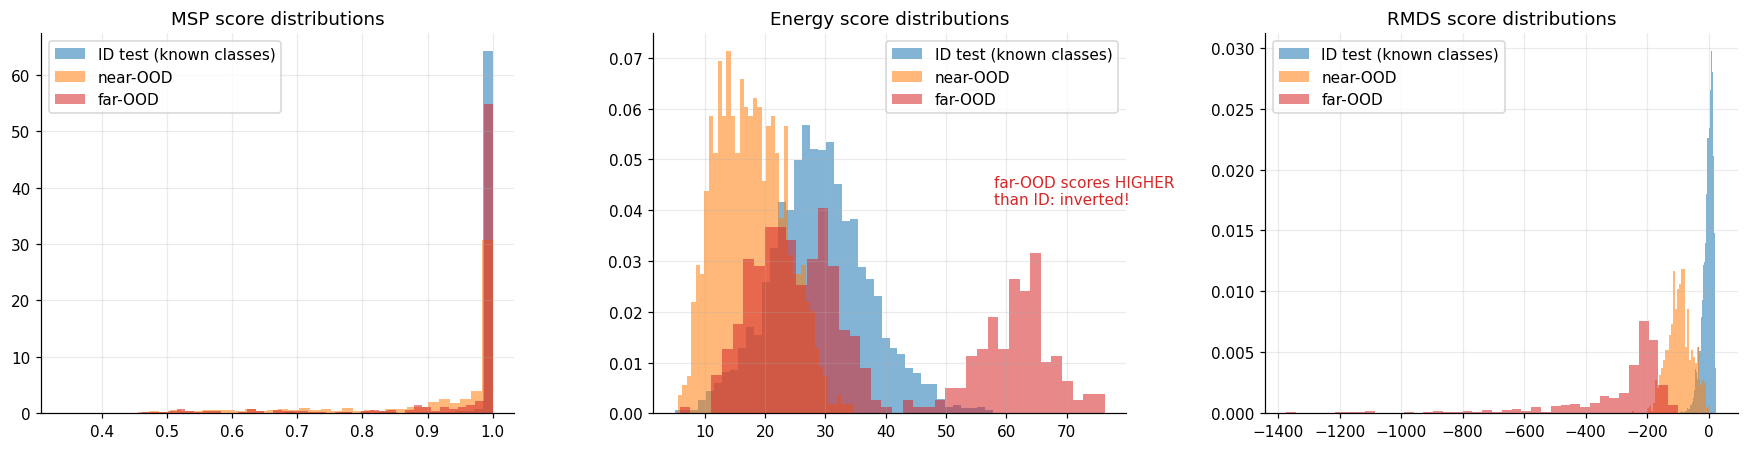

In [12]:
# --- Score distributions: the good, the bad, the inverted -----------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, name in zip(axes, ["MSP", "Energy", "RMDS"]):
    fn = SCORES[name]
    for split, label, color in [("test_id", "ID test (known classes)", "tab:blue"),
                                ("out_near", "near-OOD", "tab:orange"),
                                ("out_far", "far-OOD", "tab:red")]:
        s = fn(split)
        ax.hist(s, bins=40, density=True, alpha=0.55, label=label, color=color)
    ax.set_title(f"{name} score distributions")
    ax.legend()
axes[1].annotate("far-OOD scores HIGHER\nthan ID: inverted!",
                 xy=(0.72, 0.55), xycoords="axes fraction", color="tab:red")
plt.tight_layout(); plt.show()

## 8. Combining scores via conformal p-values

Energy, RMDS and kNN look at *different* aspects of the same input — logit scale,
class-relative density, directional neighborhood — and their errors are only partially
correlated. Combining them usually buys a point or two of AUROC, and more robustness than any
single pick. But the raw scores live on wildly different scales (probabilities, log-densities,
negative distances), so we first need a **common currency**.

**ECDF calibration = conformal p-values.** Hold out ID data (`val_A`), compute each score on
it, and map any new score value to its *rank among the held-out ID scores*:

$$
p_j(x) = \frac{1 + \#\{\, i \in \text{val}_A : s_j(x_i) \le s_j(x) \,\}}{n_A + 1}.
$$

This $p_j(x)$ is a **conformal p-value**, and it earns the name via a one-line argument:
if $x$ is a genuine ID point, it is *exchangeable* with the $n_A$ calibration points, so its
rank among them is uniform on $\{1, \dots, n_A{+}1\}$, hence
$\Pr(p_j(X) \le \alpha) \le \alpha$ — a finite-sample, distribution-free guarantee, no
assumptions on the score or the data whatsoever. Small $p_j$ = "an ID point almost never
scores this low."

**Combining.** Fisher's classic method sums the logs: the statistic
$C(x) = -2\sum_j \log p_j(x)$ follows a $\chi^2_{2m}$ distribution when the $m$ p-values are
*independent* and exactly uniform. Neither premise holds here — our p-values are correlated
(the scores read the same input through overlapping information), and conformal p-values are
discrete and only super-uniform. So we keep Fisher's *statistic* as a plain combined score
(any positive rescaling ranks identically, which is why the code sums $\log p_j$ without the
$-2$) but **discard his reference distribution** — instead we re-calibrate the combined score
itself conformally on the *second* held-out split (`val_B`, never touched so far). That
two-split structure is the whole reason we made val_A and val_B separate: calibrating a
statistic on the same data used to build it would make the p-values optimistically small.

In [13]:
# --- Conformal p-values and combined scores --------------------------------------
CANDIDATES = ["Energy", "RMDS", "kNN"]     # the trio recommended by the literature

# Per-score calibration sets from val_A (sorted for fast rank lookup).
cal_sorted = {name: np.sort(SCORES[name]("val_A")) for name in CANDIDATES}
N_A = len(X_valA)

def pvalues(split, name):
    s = SCORES[name](split)
    ranks = np.searchsorted(cal_sorted[name], s, side="right")   # #{cal <= s}
    return (1.0 + ranks) / (N_A + 1.0)

def make_combined(names):
    """Sum of log conformal p-values over `names` (monotone rescaling of Fisher's
    statistic), signed so higher = more ID."""
    def score(split):
        logs = np.stack([np.log(pvalues(split, n)) for n in names])
        return logs.sum(axis=0)             # = -C(x); higher = larger p-values = ID-like
    return score

score_trio = make_combined(["Energy", "RMDS", "kNN"])
score_duo = make_combined(["RMDS", "kNN"])

rows = []
for name, fn in ([(n, SCORES[n]) for n in CANDIDATES]
                 + [("Energy+RMDS+kNN", score_trio), ("RMDS+kNN", score_duo)]):
    s_id = fn("test_id")
    rows.append([name,
                 auroc(s_id, fn("out_near")), auroc(s_id, fn("out_far")),
                 fpr_at_tpr(s_id, fn("out_near")), fpr_at_tpr(s_id, fn("out_far"))])
show_table(["score", "AUROC near", "AUROC far", "FPR95 near", "FPR95 far"], rows)

score            AUROC near  AUROC far  FPR95 near  FPR95 far
-------------------------------------------------------------
Energy           0.883       0.441      0.563       0.938    
RMDS             0.982       1.000      0.093       0.000    
kNN              0.957       0.971      0.257       0.204    
Energy+RMDS+kNN  0.986       0.995      0.060       0.000    
RMDS+kNN         0.986       0.999      0.068       0.000    


Two things happened in that table. The p-value machinery did its job — RMDS+kNN combine into
a score as good as (or better than) either alone, on a common scale. The trio is the more
surprising row: it carries a component that is *inverted* on far-OOD, yet gives up almost
nothing. That damage tolerance is a real property of the rank transform, worth understanding:
each component contributes $\log p_j$, and a conformal p-value is bounded below by
$1/(n_A{+}1)$, so even a maximally broken component can shift the combined score by at most
$\log(n_A{+}1)$ nats — whereas summing *raw* scores would let one runaway component drag the
total arbitrarily far. Robustness is not a reason to keep energy, though: it adds complexity
and a known failure mode while buying nothing measurable, and §9 will make the case for
dropping it with legitimate data.

Because notice what we used to *diagnose* energy in the first place: a table computed on over
a thousand labeled test outliers. In deployment you will never have that. Every
outlier-informed decision — which components to keep, which method wins — has to be made from
the **60 examples you actually have**. That is the subject of §9.

## 9. The 60 outliers' real jobs: selection and measurement (not fitting)

Start with the decision that does **not** need outliers at all, because it has a beautiful
asymmetry to it:

**Controlling the false-reject rate needs no outliers.** You want "at most $\alpha$ of
genuine known-class inputs get rejected." Take the final score on `val_B` ($n_B$ held-out ID
points) and compute the conformal p-value of each new input against it, rejecting when
$p(x) \le \alpha$. By the same exchangeability argument as §8, for any genuine ID input,
$\Pr(\text{reject}) \le \alpha$ — **guaranteed, in finite samples, with zero knowledge of the
outlier distribution.** This is the conformal / ID-quantile threshold, and it is the right
default: the guarantee covers the error you can control, and it never touches the precious
outlier examples.

**Everything about outliers, you can only learn from outliers.** Nothing about
$p_{\text{in}}$ can tell you what fraction of *future novelty* you will catch — that depends
entirely on where $p_{\text{out}}$ puts its mass. The 60 examples have exactly two legitimate
jobs, and it pays to keep them distinct:

1. **Selection** — decide *which* score to deploy: rank the candidates (and combinations) by
   AUROC against the 60, with bootstrap error bars, and prefer the robust default unless a
   challenger beats it by more than the noise. This is where a weak component like our
   energy score gets demoted legitimately.
2. **Measurement** — at the chosen threshold, count how many of the 60 are rejected and put
   a **binomial confidence interval** on it (we use Wilson's interval, which behaves well at
   $n = 60$). The width of that interval *is* your honest uncertainty about the detection
   rate; report the interval, not the point.

And one job they must **not** be given: training data for a supervised outlier classifier
(§10 shows why).

### 9.1 Selection on the 60, with error bars

AUROC computed against 60 outliers is a noisy random variable — resampling the 60 with
replacement (the bootstrap) shows *how* noisy. And to compare two candidate scores, bootstrap
the **difference** of their AUROCs on the *same* resamples: pairing cancels the shared
sampling noise, and the honest question becomes whether the difference's CI excludes zero.

One bookkeeping note: the AUROCs below use `test_id` as their **ID side**. Among our splits it
is the only legitimate choice — `val_A` is in-sample for the combined candidates (their
p-values are ECDF-calibrated on it, so its own combined scores are biased high), and selecting
on `val_B` would couple the choice of deployed score to the very calibration set that §9.2's
threshold guarantee relies on staying untouched. The ID side of a selection AUROC is not
outlier information, so this spends nothing scarce — but in your own pipeline, budget a
separate held-out ID slice for this role rather than discovering the need mid-experiment.

candidate        AUROC vs the 60  bootstrap sd
----------------------------------------------
Energy           0.846            0.019       
RMDS             0.975            0.007       
kNN              0.953            0.006       
Energy+RMDS+kNN  0.984            0.004       
RMDS+kNN         0.984            0.006       

candidate        AUROC, near type A (n=20)  AUROC, near type B (n=20)  AUROC, far type (n=20)
---------------------------------------------------------------------------------------------
Energy           0.781                      0.955                      0.802                 
RMDS             0.999                      0.928                      1.000                 
kNN              0.974                      0.949                      0.935                 
Energy+RMDS+kNN  0.992                      0.966                      0.992                 
RMDS+kNN         0.998                      0.957                      0.998                 


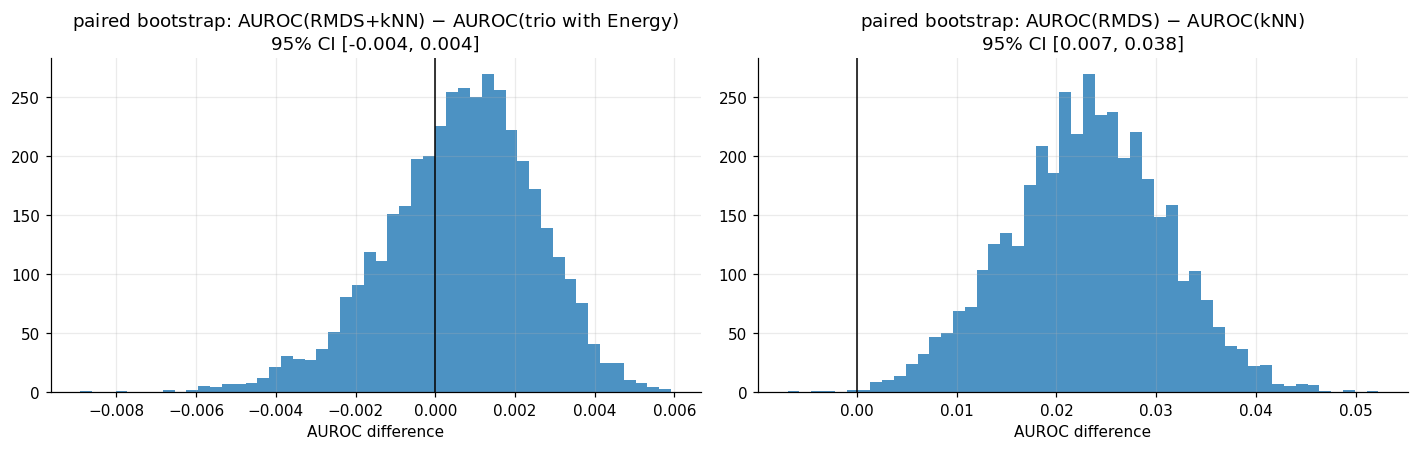

paired 95% CI for AUROC(duo) - AUROC(trio): [-0.004, 0.004]

decision: drop Energy. It is the clearly weakest candidate on the 60 (ten-plus
AUROC points behind, far outside the bootstrap noise), it lags on two of the
three known outlier types, and adding it to the combination buys nothing
(the duo-trio CI is centered on zero). A component that costs complexity and
adds no measurable value does not go to deployment.
final deployed score: conformal-p-value combination of RMDS + kNN


In [14]:
# --- Selection: rank the candidates against the 60, bootstrap the differences ----
SELECT = {
    "Energy": SCORES["Energy"], "RMDS": SCORES["RMDS"], "kNN": SCORES["kNN"],
    "Energy+RMDS+kNN": score_trio, "RMDS+kNN": score_duo,
}
s_id_sel = {n: fn("test_id") for n, fn in SELECT.items()}
s_cal60 = {n: fn("out_cal") for n, fn in SELECT.items()}

B = 4000
idx = rng.integers(0, 60, size=(B, 60))            # resample the 60 outliers
boot = {n: np.array([auroc(s_id_sel[n], s_cal60[n][ix]) for ix in idx]) for n in SELECT}

rows = [[n, auroc(s_id_sel[n], s_cal60[n]), boot[n].std()] for n in SELECT]
show_table(["candidate", "AUROC vs the 60", "bootstrap sd"], rows)

# Slice the 60 by outlier type. You know where YOUR 60 came from -- use that
# structure: aggregates can hide a failure mode that one type exposes.
out_cal_type = np.repeat([0, 1, 2], 20)      # class each example came from (see section 4)
type_names = ["near type A", "near type B", "far type"]
print()
rows = [[n] + [auroc(s_id_sel[n], s_cal60[n][out_cal_type == t]) for t in range(3)]
        for n in SELECT]
show_table(["candidate"] + [f"AUROC, {t} (n=20)" for t in type_names], rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
diff_ed = boot["RMDS+kNN"] - boot["Energy+RMDS+kNN"]   # paired: same resamples
diff_rk = boot["RMDS"] - boot["kNN"]
for ax, diff, title in [(axes[0], diff_ed, "AUROC(RMDS+kNN) $-$ AUROC(trio with Energy)"),
                        (axes[1], diff_rk, "AUROC(RMDS) $-$ AUROC(kNN)")]:
    ax.hist(diff, bins=50, alpha=0.8)
    ax.axvline(0, color="black", lw=1)
    ax.set_title(f"paired bootstrap: {title}\n95% CI "
                 f"[{np.quantile(diff, .025):.3f}, {np.quantile(diff, .975):.3f}]")
    ax.set_xlabel("AUROC difference")
plt.tight_layout(); plt.show()

score_final = score_duo
print(f"paired 95% CI for AUROC(duo) - AUROC(trio): "
      f"[{np.quantile(diff_ed, .025):.3f}, {np.quantile(diff_ed, .975):.3f}]")
print()
print("decision: drop Energy. It is the clearly weakest candidate on the 60 (ten-plus")
print("AUROC points behind, far outside the bootstrap noise), it lags on two of the")
print("three known outlier types, and adding it to the combination buys nothing")
print("(the duo-trio CI is centered on zero). A component that costs complexity and")
print("adds no measurable value does not go to deployment.")
print("final deployed score: conformal-p-value combination of RMDS + kNN")

How to read the selection output — three lessons, in increasing order of subtlety:

- **The aggregate table demotes energy legitimately**: ten-plus AUROC points behind the
  density scores, far outside the bootstrap noise, and contributing nothing to the
  combination. That is a clean, 60-examples-only justification for dropping it.
- **Now compare against §7's big-test table, which a deployed system would never see.**
  Energy's true far-OOD AUROC was catastrophic — *below 0.5* — yet on the far-type slice of
  the 60 it merely limps around 0.8. Why? The one far class that happened to be among your
  collected outliers is one where energy sort-of works; the classes where it inverts are all
  in the "unseen" pile. This is the sharpest limitation of small outlier sets, sharper than
  the CI widths: **the 60 can demote a candidate, but they can never certify one** — they
  are silent about every outlier type they don't contain. Two practical consequences: slice
  your outliers by every type you know (an aggregate can average a failure into
  respectability), and let theory-level diagnoses (like §6.1's "energy is suspect when
  inputs are unbounded") carry real weight alongside measurement — the measurement you can
  afford is provably incomplete.
- **Among the healthy candidates, differences are small.** RMDS edges out kNN; whether that
  paired CI clears zero varies run to run — either way the gap is a couple of points, and
  the combination matches the best single candidate while hedging against future outlier
  types where today's runner-up wins. At $n = 60$, prefer the robust default over the
  leaderboard winner.

### 9.2 The threshold: conformal on ID, measured on the 60

With the score chosen, set the threshold **using held-out ID data only** (`val_B`, untouched
so far) at $\alpha = 0.05$, then *measure* what it buys on every outlier group we have.

In [15]:
# --- Conformal threshold at alpha = 0.05, then honest measurement ----------------
ALPHA = 0.05
cal_B = np.sort(score_final("val_B"))
N_B = len(cal_B)

def conformal_p(split):
    s = score_final(split)
    return (1.0 + np.searchsorted(cal_B, s, side="right")) / (N_B + 1.0)

def reject_rate(split):
    return (conformal_p(split) <= ALPHA).mean()

def wilson_ci(k, n, z=1.96):
    p = k / n
    center = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return center - half, center + half

print(f"target ID false-reject rate alpha = {ALPHA}")
print(f"actual ID false-reject rate (test_id, n={len(X_test)}): {reject_rate('test_id'):.3f}")
print()

k60 = int((conformal_p("out_cal") <= ALPHA).sum())
lo, hi = wilson_ci(k60, 60)
print(f"detection on the 60 collected outliers: {k60}/60 = {k60/60:.3f}   "
      f"Wilson 95% CI [{lo:.3f}, {hi:.3f}]  <-- note the width!")
print()
for split, label in [("out_seen", "outliers, SEEN classes (fresh samples)"),
                     ("out_unseen", "outliers, UNSEEN classes"),
                     ("out_near", "outliers, near-OOD"),
                     ("out_far", "outliers, far-OOD")]:
    print(f"detection rate on {label:42s}: {reject_rate(split):.3f}")

target ID false-reject rate alpha = 0.05


actual ID false-reject rate (test_id, n=2400): 0.050

detection on the 60 collected outliers: 56/60 = 0.933   Wilson 95% CI [0.841, 0.974]  <-- note the width!

detection rate on outliers, SEEN classes (fresh samples)    : 0.893
detection rate on outliers, UNSEEN classes                  : 0.996


detection rate on outliers, near-OOD                        : 0.932
detection rate on outliers, far-OOD                         : 1.000


Three lessons hide in that printout:

- The ID false-reject rate lands at (or below) the promised 5% *without ever using an
  outlier* — the conformal guarantee doing its job.
- The Wilson interval on 60 examples spans 13 percentage points — and that is the *favorable*
  case, with detection up around 90%; near a 50% detection rate the same interval balloons
  to nearly 25 points. Any decision that hinges on "our detection rate is 87% vs 82%" is **not
  supported by 60 examples**. Decisions the 60 *can* support: "clearly above 50%," "method A
  beats method B by 15+ points," "this component lags badly."
- Also note the near/far breakdown: near-OOD detection at a fixed 5% false-reject budget is
  *much* lower than far-OOD detection. That is the honest number to set expectations with —
  promising stakeholders the far-OOD number is how OOD systems end up "not working" in
  production.

## 10. The tempting mistake: a supervised outlier classifier on the 60

"We have labeled outliers — let's just train ID-vs-outlier logistic regression on the
features!" This is the single most tempting wrong move in this whole problem, and with 60
examples it fails for a crisp reason: **a discriminative boundary only constrains the
directions the 60 examples happen to occupy.** Novel classes arriving from *any other
direction* land on whatever side of the hyperplane geometry dictates — usually the ID side,
because the boundary was never asked to enclose the ID data, only to separate it from three
specific intruders. Density models enclose; discriminators separate.

We can demonstrate this exactly, because our test set contains outliers from the 3 *seen*
classes and from 5 *never-seen* classes:

In [16]:
# --- Supervised ID-vs-outlier head: great on seen classes, brittle on unseen -----
sup_X = np.vstack([FEAT["val_A"], FEAT["out_cal"]])
sup_y = np.concatenate([np.zeros(len(X_valA)), np.ones(60)])
sup = LogisticRegression(max_iter=2000, class_weight="balanced").fit(sup_X, sup_y)

def score_supervised(split):
    return -sup.decision_function(FEAT[split])     # higher = more ID, as elsewhere

rows = []
for name, fn in [("supervised (trained on the 60)", score_supervised),
                 ("RMDS+kNN (unsupervised)", score_final)]:
    s_id = fn("test_id")
    rows.append([name,
                 auroc(s_id, fn("out_cal")),
                 auroc(s_id, fn("out_seen")),
                 auroc(s_id, fn("out_unseen"))])
show_table(["score", "AUROC vs the 60", "AUROC seen classes", "AUROC UNSEEN classes"], rows)

score                           AUROC vs the 60  AUROC seen classes  AUROC UNSEEN classes
-----------------------------------------------------------------------------------------
supervised (trained on the 60)  0.999            0.989               0.553               
RMDS+kNN (unsupervised)         0.984            0.980               0.997               


The pattern to expect: the supervised head looks *spectacular* on the 60 it trained on and
very good on fresh samples from those same 3 classes — and then gives back most (sometimes
all) of its advantage on the 5 classes it never saw, where the unsupervised density
combination keeps working. If you had validated on a held-out chunk of your 60, you would
have *concluded the supervised model was better* and shipped the fragile one. The unseen-class
column is the only one that predicts next month's novelty.

(With hundreds-to-thousands of diverse outliers, the calculus changes — *outlier exposure*
fine-tuning genuinely helps. At $n=60$ from 3 classes, it is a trap.)

## 11. The full open-set pipeline

Everything assembled into one deployable object. Design decisions worth restating:

- **Post-hoc:** wraps any classifier exposing features + logits; nothing retrained.
- **Score:** conformal-p-value combination (§8) of the components that survived selection —
  on this data, RMDS + kNN, with energy dropped by the §9.1 procedure. The class still
  computes energy so that on *your* data the selection can go the other way: `components`
  is a constructor argument.
- **Threshold:** conformal on held-out ID at user-chosen $\alpha$ (§9.2) — the only free
  parameter, and it means exactly "I accept losing an $\alpha$ fraction of good inputs."
- **The 60 outliers appear nowhere in fitting** — they are reserved for selection and
  measurement, keeping the measurement honest.

In [17]:
# --- OpenSetClassifier: the deliverable ------------------------------------------
class OpenSetClassifier:
    """Open-set wrapper: classify among known classes or reject as unknown.

    Parameters
    ----------
    feature_fn : X -> (n, d) penultimate features of the base classifier
    logit_fn   : X -> (n, C) logits of the base classifier
    alpha      : target false-reject rate on in-distribution inputs
    k          : neighbors for the kNN score
    components : which scores to combine — pick them with the §9.1 selection
                 procedure on YOUR outlier examples; "energy" is available too
    """

    REJECT = -1

    def __init__(self, feature_fn, logit_fn, alpha=0.05, k=25,
                 components=("rmds", "knn")):
        self.feature_fn, self.logit_fn = feature_fn, logit_fn
        self.alpha, self.k = alpha, k
        self.components = list(components)

    @staticmethod
    def _l2(Z):
        return Z / np.clip(np.linalg.norm(Z, axis=1, keepdims=True), 1e-12, None)

    def fit(self, X_train, y_train, X_val_a, X_val_b):
        Z = self.feature_fn(X_train)
        C = int(y_train.max()) + 1
        self.mu_c_ = np.stack([Z[y_train == c].mean(axis=0) for c in range(C)])
        self.prec_ = LedoitWolf().fit(Z - self.mu_c_[y_train]).precision_
        bg = LedoitWolf().fit(Z)
        self.mu0_, self.prec0_ = Z.mean(axis=0), bg.precision_
        self.nn_ = NearestNeighbors(n_neighbors=self.k).fit(self._l2(Z))
        # calibration: per-score ECDF on val_A, combined-score ECDF on val_B
        self.cal_a_ = {n: np.sort(s) for n, s in self._raw_scores(X_val_a).items()}
        self.cal_b_ = np.sort(self._combined(X_val_b))
        return self

    def _raw_scores(self, X):
        Z, L = self.feature_fn(X), self.logit_fn(X)
        d2c = np.stack([np.einsum("nd,dk,nk->n", Z - m, self.prec_, Z - m)
                        for m in self.mu_c_], axis=1)
        d20 = np.einsum("nd,dk,nk->n", Z - self.mu0_, self.prec0_, Z - self.mu0_)
        dk, _ = self.nn_.kneighbors(self._l2(Z))
        return {"energy": logsumexp(L, axis=1),
                "rmds": -(d2c - d20[:, None]).min(axis=1),
                "knn": -dk[:, -1]}

    def _combined(self, X):
        raw = self._raw_scores(X)
        logp = [np.log((1 + np.searchsorted(self.cal_a_[n], raw[n], side="right"))
                       / (len(self.cal_a_[n]) + 1.0)) for n in self.components]
        return np.sum(logp, axis=0)

    def pvalue(self, X):
        s = self._combined(X)
        return (1 + np.searchsorted(self.cal_b_, s, side="right")) / (len(self.cal_b_) + 1.0)

    def predict(self, X):
        labels = self.logit_fn(X).argmax(axis=1)
        labels[self.pvalue(X) <= self.alpha] = self.REJECT
        return labels


osc = OpenSetClassifier(feature_fn=lambda X: forward(X)[0],
                        logit_fn=lambda X: forward(X)[1],
                        alpha=0.05,
                        components=("rmds", "knn")).fit(X_train, y_train, X_valA, X_valB)

pred_id = osc.predict(X_test)
accepted = pred_id != OpenSetClassifier.REJECT
print("=== Final open-set report (alpha = 0.05) ===")
print(f"ID test:      accepted {accepted.mean():.3f}   "
      f"accuracy among accepted {(pred_id[accepted] == y_test[accepted]).mean():.3f}")
for split, X in [("60 collected outliers", X_out_cal),
                 ("outlier test, seen classes", X_out_seen),
                 ("outlier test, UNSEEN classes", X_out_unseen)]:
    rej = (osc.predict(X) == OpenSetClassifier.REJECT).mean()
    print(f"{split:29s}: rejected {rej:.3f}")

=== Final open-set report (alpha = 0.05) ===
ID test:      accepted 0.950   accuracy among accepted 0.975
60 collected outliers        : rejected 0.933
outlier test, seen classes   : rejected 0.893
outlier test, UNSEEN classes : rejected 0.996


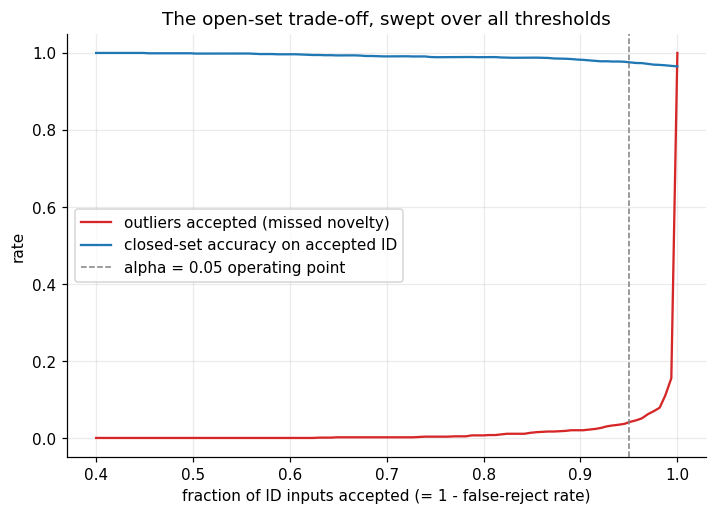

Moving left (stricter threshold) buys outlier rejection and slightly cleaner
accepted predictions, at the price of rejecting more genuine inputs.


In [18]:
# --- The operating curve: what alpha buys you -------------------------------------
# Sweep the threshold over the whole range and trace both error types.
s_id = score_final("test_id")
s_out = score_final("out_all")
closed_correct = LOGIT["test_id"].argmax(axis=1) == y_test

taus = np.quantile(s_id, np.linspace(0.0, 0.6, 100))
id_accept = [(s_id >= t).mean() for t in taus]
out_accept = [(s_out >= t).mean() for t in taus]
acc_on_accepted = [closed_correct[s_id >= t].mean() for t in taus]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(id_accept, out_accept, label="outliers accepted (missed novelty)", c="tab:red")
ax.plot(id_accept, acc_on_accepted, label="closed-set accuracy on accepted ID", c="tab:blue")
ax.axvline(0.95, color="gray", ls="--", lw=1, label="alpha = 0.05 operating point")
ax.set_xlabel("fraction of ID inputs accepted (= 1 - false-reject rate)")
ax.set_ylabel("rate")
ax.set_title("The open-set trade-off, swept over all thresholds")
ax.legend()
plt.show()
print("Moving left (stricter threshold) buys outlier rejection and slightly cleaner")
print("accepted predictions, at the price of rejecting more genuine inputs.")

## 12. Taking this to your real problem

A concrete, ordered checklist:

1. **Extract penultimate features and logits** from your existing 30-class model for: the
   train set, *three* held-out ID splits (a few hundred each is plenty — one for ECDF
   calibration, one for the conformal threshold, one as the ID side of selection AUROCs and
   final measurement), and your 60 outliers.
2. **Implement the candidates** — energy (3 lines), RMDS (Ledoit–Wolf shrinkage, pooled
   covariance), deep-kNN on L2-normalized features. Each is ~20 lines; you have reference
   implementations above.
3. **Select with error bars** (§9.1): AUROC of each candidate and of the p-value combinations
   against your 60, with paired bootstraps, sliced by outlier type. Expect CIs among the
   *good* candidates to overlap — keep the combination unless a single score wins clearly —
   and drop candidates that clearly lag or invert on any type. Remember the asymmetry: the
   60 can demote a candidate but never certify one against outlier types they don't contain,
   so keep theory-level suspicions (energy on unbounded inputs, Mahalanobis under tiny
   per-class counts) in play even when the numbers look fine.
4. **Threshold conformally on ID only** at the $\alpha$ your product tolerates, then *measure*
   the detection rate on the 60 with a Wilson interval — and report that interval, not the
   point estimate, to whoever owns the requirements.
5. **Split the 60's budget** if you iterate: e.g. 30 for selection experiments, 30 never
   touched until the final measurement. Reusing all 60 for both selection and measurement
   biases the reported detection rate upward (winner's curse).
6. **Re-run the comparison after every classifier retrain.** Post-hoc scores are functions of
   the feature space; a retrain can silently reshape it. Gate the new model on closed-set
   accuracy *and* detection AUROC.

Pitfalls, in decreasing order of how often they bite:

- **Leakage**: any outlier example influencing anything that is later *measured* on outliers
  (feature selection, score choice, threshold). The split discipline of §4 exists for this.
- **Unshrunk covariance** with few samples per class — Mahalanobis silently degrades to noise.
- **Evaluating only on far/synthetic outliers** — flatters every method; near-OOD is the real
  test and roughly bounds what you should promise.
- **Trusting one AUROC point estimate at $n=60$** — ±4–6 points of noise is normal.
- **The supervised shortcut of §10.**

Where to go next, when the basics are in place and you want more:

- **Better features, same recipe:** if you can retrain, encoders trained with a margin-based
  auxiliary loss (Zhou et al., EMNLP 2021) or distance-preserving regularization (DDU-style
  spectral normalization) make the *same* post-hoc scores work better. Avoid recipes that
  collapse feature geometry (e.g. plain LogitNorm) — they break Mahalanobis/kNN.
- **Few-samples-per-class covariance:** Bayesian nonparametric Mahalanobis variants handle
  the small-$n_c$ regime more gracefully than shrinkage alone.
- **Batch decisions:** if you score inputs in batches and care about the *fraction* of false
  alarms among rejections, Benjamini–Hochberg on the conformal p-values controls the false
  discovery rate directly.
- **Rejecting misclassifications too:** the gate above only rejects *novelty*; inputs from
  known classes that the classifier will get *wrong* are a separate rejection problem
  (Chow 1970; modern treatment: SCOD plugin rules) — MSP, ironically, is a good score for
  *that* one, and the two gates compose.

## 13. References

- Hendrycks & Gimpel (ICLR 2017) — MSP baseline. [arXiv:1610.02136](https://arxiv.org/abs/1610.02136)
- Hein, Andriushchenko & Bitterwolf (CVPR 2019) — ReLU networks are provably overconfident far from data. [arXiv:1812.05720](https://arxiv.org/abs/1812.05720)
- Lee, Lee, Lee & Shin (NeurIPS 2018) — Mahalanobis detector on deep features. [arXiv:1807.03888](https://arxiv.org/abs/1807.03888)
- Ren et al. (2021) — Relative Mahalanobis distance for near-OOD. [arXiv:2106.09022](https://arxiv.org/abs/2106.09022)
- Liu, Wang, Owens & Li (NeurIPS 2020) — Energy-based OOD detection. [arXiv:2010.03759](https://arxiv.org/abs/2010.03759)
- Sun, Ming, Zhu & Li (ICML 2022) — Deep nearest neighbors for OOD. [arXiv:2204.06507](https://arxiv.org/abs/2204.06507)
- Vovk, Gammerman & Shafer — *Algorithmic Learning in a Random World* (conformal prediction).
- Chow (1970) — On optimum recognition error and reject tradeoff.
- Yang et al. — OpenOOD benchmark (v1.5), the fairest public league table of these methods. [arXiv:2306.09301](https://arxiv.org/abs/2306.09301)
- Ledoit & Wolf (2004) — Well-conditioned covariance shrinkage.